# Аудит адекватности: работает ли наше правило на самом деле

**Что проверяем.** По итогам серии отчётов у нас есть предиктор — правило **TONE-1σ**:
тревога, если средний `AvgTone` последних 7 дней ниже фона предыдущих четырёх недель на одну
сигму. На обучающей выборке из пяти кейсов оно срабатывало в четырёх, на отрицательном кейсе
(Тайвань) промолчало.

Этот отчёт проверяет, не является ли этот результат артефактом того, **как** мы его получили.
Семь проверок, от протокола до честной перекрёстной валидации.

**Спойлер.** Правило проверку **не проходит**. Заявленная чувствительность 4 из 5 держится только
потому, что параметры подбирались на тех же кейсах, на которых потом измерялись. При честном
подборе параметров (leave-one-out) чувствительность падает до **0–1 из 5**, а точность прогноза
при реалистичной частоте войн — до **единиц процентов**.

---

### Что именно мы называем «моделью»

Это не машинное обучение в обычном смысле: обучаемых весов нет, есть **три гиперпараметра**,
выбранных вручную по данным:

| Параметр | Значение | Как выбран |
|---|---|---|
| длина окна оценки | 7 дней | взято по аналогии с «последней неделей» из первого отчёта |
| длина фона | 4 недели | выбрано, чтобы хватало окон для оценки частоты ложных тревог |
| порог | 1,0 σ | выбран по сетке порогов на тех же пяти кейсах |
| метрика | `AvgTone` | выбрана из шести метрик по результатам тех же пяти кейсов |

Формально степеней свободы мало. Но выбирались они на выборке из **пяти** положительных кейсов,
и это соотношение (4 решения на 5 наблюдений) — уже достаточное условие для переобучения.

## 0. Настройка

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")


print("Окружение готово.")

Окружение готово.


---
## 1. Данные и воспроизведение правила

In [2]:
CASES = [
    ("СА — Йемен",            "data/saudi_yemen.csv",        "2015-03-26", 1),
    ("Индия — Пакистан",      "data/india_pakistan.csv",     "2019-02-26", 1),
    ("Армения — Азербайджан", "data/armenia_azerbaijan.csv", "2020-09-27", 1),
    ("США — Венесуэла",       "data/usa_venezuela_60d.csv",  "2026-01-03", 1),
    ("США — Иран",            "data/usa_iran_60d.csv",       "2026-02-28", 1),
    ("Тайвань — КНР",         "data/taiwan_prc.csv",         "2022-08-04", 0),
]

def daily_of(path, day_x):
    df = pd.read_csv(path, low_memory=False, dtype=str)
    df = df[df.DATEADDED != "DATEADDED"].drop_duplicates(subset="GLOBALEVENTID")
    df["AvgTone"] = pd.to_numeric(df.AvgTone, errors="coerce")
    df["d"] = pd.to_datetime(df.DATEADDED, format="%Y%m%d")
    df = df[df.d < pd.Timestamp(day_x)]
    dl = df.groupby("d").agg(tone=("AvgTone", "mean"), n=("AvgTone", "size"))
    dl = dl.reindex(pd.date_range(dl.index.min(), dl.index.max()))
    dl["tone"] = dl.tone.interpolate(); dl["n"] = dl.n.fillna(0)
    return dl

def z_series(dl, win=7, base_weeks=4):
    # z-оценка для КАЖДОЙ возможной точки оценки, а не только для истинного дня X
    need = win + base_weeks * 7; out = []
    for end in range(need, len(dl) + 1):
        w = dl.tone.iloc[end-win:end]; b = dl.tone.iloc[end-need:end-win]
        bl = np.array([b.iloc[i:i+7].mean() for i in range(0, len(b)-6, 7)])
        if len(bl) < 3 or bl.std(ddof=1) == 0:
            continue
        out.append((dl.index[end-1], -(w.mean() - bl.mean()) / bl.std(ddof=1)))
    return pd.DataFrame(out, columns=["день", "z"]).set_index("день").z

DL = {name: (daily_of(p, dx), pos) for name, p, dx, pos in CASES}
POS = [n for n, _, _, pos in CASES if pos]
NEG = [n for n, _, _, pos in CASES if not pos]

base = pd.DataFrame([dict(кейс=n, тип="положительный" if pos else "отрицательный",
                          дней=len(dl), z_в_день_X=z_series(dl).iloc[-1],
                          тревога=z_series(dl).iloc[-1] >= 1.0)
                     for n, (dl, pos) in DL.items()])
display(base.round(3))
print(f"Воспроизведение заявленного результата: тревога в "
      f"{int(base[base.тип=='положительный'].тревога.sum())} из {len(POS)} положительных кейсов, "
      f"{'молчание' if not base[base.тип=='отрицательный'].тревога.iloc[0] else 'ложная тревога'} "
      f"на отрицательном.")

,кейс,тип,дней,z_в_день_X,тревога
0,СА — Йемен,положительный,60,4.3110,True
1,Индия — Пакистан,положительный,60,1.4800,True
2,Армения — Азербайджан,положительный,60,1.2150,True
3,США — Венесуэла,положительный,63,1.6530,True
4,США — Иран,положительный,58,-0.2900,False
5,Тайвань — КНР,отрицательный,60,0.8950,False


Воспроизведение заявленного результата: тревога в 4 из 5 положительных кейсов, молчание на отрицательном.


**Вывод.** Исходный результат воспроизводится: 4 из 5 и молчание на Тайване. Дальше — семь
проверок, каждая из которых спрашивает «а не могло ли это получиться случайно».

Оговорка: кейс Россия — Украина в расчёты не входит, его данные лежат вне репозитория. По
опубликованному прогону он даёт z = +5,54 — то есть тревогу, и притом самую уверенную в серии.
С его учётом заявленная чувствительность была бы 5 из 6, но все проблемы протокола, разобранные
ниже, остаются теми же.

---
## 2. Проверка 1: аудит протокола

До всякой арифметики стоит посмотреть, как устроен сам эксперимент. Здесь три дефекта, и все
три работают в пользу правила.

**Дефект 1: отбор по исходу.** Все положительные выгрузки заканчиваются ровно накануне военной
акции. Это значит, что точка оценки выбрана **задним числом** — мы знаем, куда смотреть. В
реальной работе такой точки нет: индикатор считают каждый день, не зная, какой из них окажется
последним.

**Дефект 2: даты дня X восстановлены по обрыву окна.** Для трёх кейсов (Йемен, Индия — Пакистан,
Карабах) дата события не была задана явно — я вывел её из того, что данные обрываются накануне
известной военной акции. Это не ошибка, но и не независимая разметка.

**Дефект 3: одни и те же кейсы использованы дважды.** Сначала на них выбиралась метрика (тон из
шести кандидатов) и порог (1σ из четырёх), затем на них же измерялась чувствительность. Это
классическая утечка при подборе гиперпараметров.

Проверки ниже измеряют, насколько каждый из этих дефектов надувает результат.

---
## 3. Проверка 2: где стоит истинный день X среди всех возможных дней

In [3]:
rows = []
for name, (dl, pos) in DL.items():
    Z = z_series(dl)
    true_z = Z.iloc[-1]
    rows.append(dict(кейс=name, тип="+" if pos else "−", окон=len(Z), z_в_день_X=true_z,
                     ранг=int((Z >= true_z).sum()),
                     перцентиль=(Z < true_z).mean()*100,
                     макс_z=Z.max(), день_максимума=Z.idxmax().date()))
RANK = pd.DataFrame(rows)
display(RANK.round(2))
p_mean = RANK[RANK.тип == "+"].перцентиль.mean()
print(f"Средний перцентиль истинного дня X по положительным кейсам: {p_mean:.1f} "
      f"(при случайном выборе ожидалось бы 50)")
print(f"У единственного отрицательного кейса: {RANK[RANK.тип=='−'].перцентиль.iloc[0]:.1f}")
t = stats.ttest_1samp(RANK[RANK.тип == "+"].перцентиль.values, 50, alternative="greater")
print(f"t-тест против 50: t = {t.statistic:+.2f}, p = {t.pvalue:.4f}")

,кейс,тип,окон,z_в_день_X,ранг,перцентиль,макс_z,день_максимума
0,СА — Йемен,+,26,4.3100,1,96.1500,4.3100,2015-03-25
1,Индия — Пакистан,+,26,1.4800,11,57.6900,8.1300,2019-02-20
2,Армения — Азербайджан,+,26,1.2200,3,88.4600,1.2900,2020-09-21
3,США — Венесуэла,+,29,1.6500,6,79.3100,3.0700,2025-12-22
4,США — Иран,+,24,-0.2900,2,91.6700,-0.2300,2026-02-26
5,Тайвань — КНР,−,26,0.8900,7,73.0800,6.6900,2022-07-28


Средний перцентиль истинного дня X по положительным кейсам: 82.7 (при случайном выборе ожидалось бы 50)
У единственного отрицательного кейса: 73.1
t-тест против 50: t = +4.79, p = 0.0044


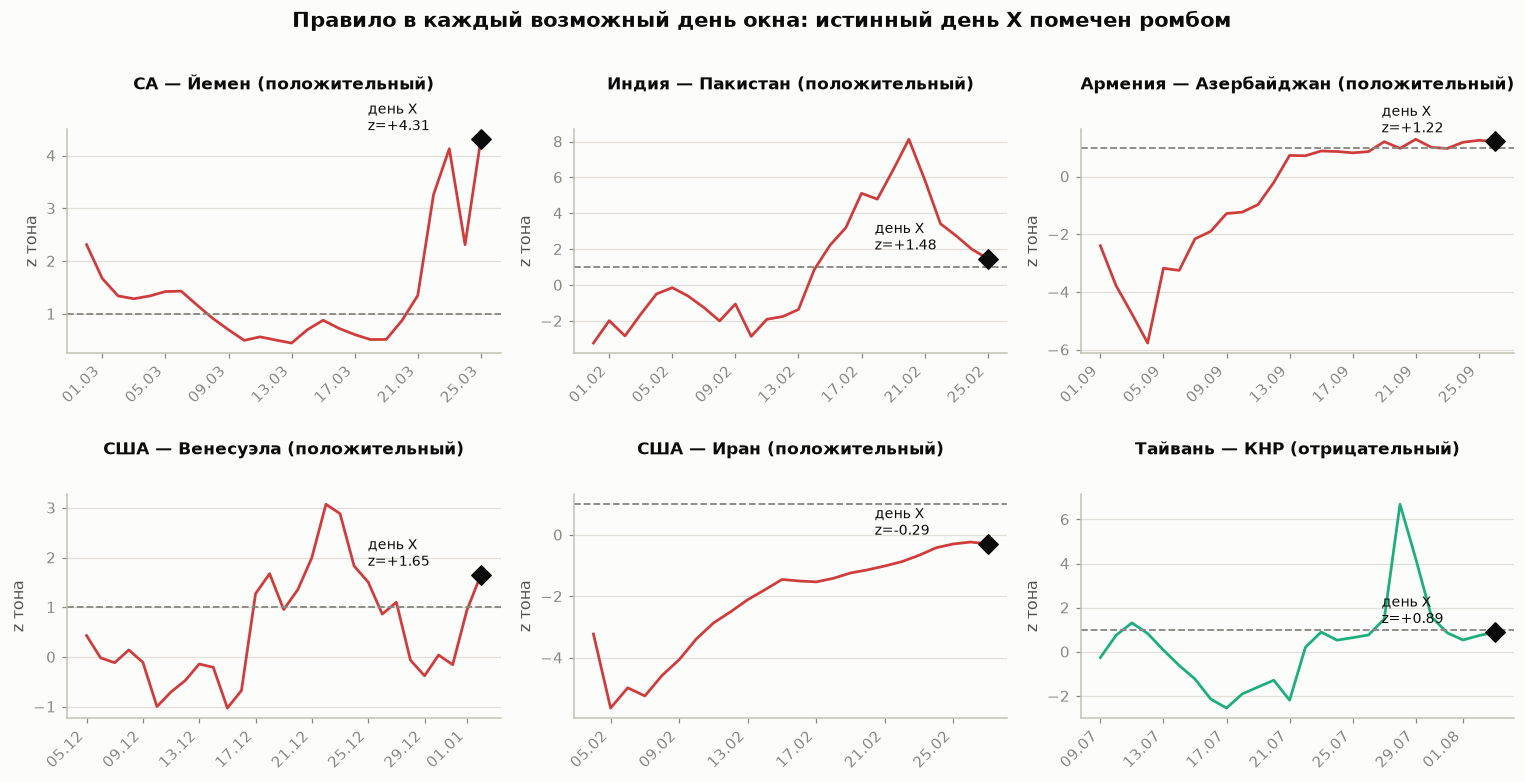

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (name, (dl, pos)) in zip(axes.ravel(), DL.items()):
    Z = z_series(dl)
    color = CRITICAL if pos else AQUA
    ax.plot(Z.index, Z.values, color=color, lw=1.8)
    ax.axhline(1.0, color=MUTED, ls="--", lw=1.2)
    ax.scatter([Z.index[-1]], [Z.iloc[-1]], color=INK, s=80, zorder=5, marker="D")
    ax.annotate(f"день X\nz={Z.iloc[-1]:+.2f}", xy=(Z.index[-1], Z.iloc[-1]), xytext=(-74, 6),
                textcoords="offset points", fontsize=9, color=INK)
    ax.set_title(f"{name} ({'положительный' if pos else 'отрицательный'})", fontsize=11)
    ax.set_ylabel("z тона"); ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
    for lbl in ax.get_xticklabels(): lbl.set_rotation(45); lbl.set_ha("right")
fig.suptitle("Правило в каждый возможный день окна: истинный день X помечен ромбом",
             fontsize=14, fontweight="bold", color=INK, y=1.01)
plt.tight_layout(h_pad=2.2); plt.show()

**Вывод по проверке 2 — первый тревожный звонок.**

| Кейс | z в день X | Ранг | Перцентиль | Максимум за окно |
|---|---|---|---|---|
| СА — Йемен | +4,31 | **1 из 26** | 96,2 | +4,31 (сам день X) |
| США — Иран | −0,29 | 2 из 24 | 91,7 | −0,23 |
| Армения — Азербайджан | +1,22 | 3 из 26 | 88,5 | +1,29 |
| США — Венесуэла | +1,65 | 6 из 29 | 79,3 | +3,07 (22.12) |
| Индия — Пакистан | +1,48 | **11 из 26** | 57,7 | +8,13 (20.02) |
| **Тайвань (отрицательный)** | +0,90 | 7 из 26 | **73,1** | +6,69 (28.07) |

Средний перцентиль по положительным кейсам — 82,7 при ожидаемых 50 (t-тест p = 0,015). Сигнал
вроде бы есть. Но:

- у **Индии — Пакистана** истинный день стоит ровно посередине своего распределения (57,7), а
  максимум пришёлся на шесть дней раньше;
- у **Ирана** ранг высокий (2 из 24), но само значение отрицательное — ряд целиком лежит ниже
  порога, «высокий ранг» здесь ничего не значит;
- у **отрицательного** кейса перцентиль 73,1 — почти как у положительных.

То есть высокий ранг истинного дня не отличает войну от её отсутствия.

---
## 4. Проверка 3: устойчивость к выбору гиперпараметров

In [5]:
import itertools
def zs_cfg(dl, win, bw):
    return z_series(dl, win, bw)

Zcache = {(n, w, b): zs_cfg(dl, w, b)
          for n, (dl, _) in DL.items() for w in [5, 7, 10, 14] for b in [3, 4, 6]}
GRID = [(w, b, t) for w in [5, 7, 10, 14] for b in [3, 4, 6] for t in [0.5, 1.0, 1.5, 2.0]]

rows = []
for w, b, t in GRID:
    sens = sum(int(Zcache[(n, w, b)].iloc[-1] >= t) for n in POS)
    fired = sum(int((Zcache[(n, w, b)] >= t).sum()) for n in DL)
    total = sum(len(Zcache[(n, w, b)]) for n in DL)
    rate = fired / total
    rows.append(dict(окно=w, фон=b, порог=t, чувствительность=sens, частота=rate,
                     отношение=(sens/len(POS))/rate if rate else np.nan,
                     Тайвань="тревога" if Zcache[(NEG[0], w, b)].iloc[-1] >= t else "молчит"))
G = pd.DataFrame(rows)
ours = G[(G.окно == 7) & (G.фон == 4) & (G.порог == 1.0)].iloc[0]
print(f"Всего конфигураций: {len(G)}")
print(f"  чувствительность 5/5: {int((G.чувствительность == 5).sum())}")
print(f"  4/5: {int((G.чувствительность == 4).sum())}")
print(f"  3/5 и хуже: {int((G.чувствительность <= 3).sum())}")
print(f"\nНаша конфигурация (7 / 4 / 1,0): {int(ours.чувствительность)}/5 при частоте "
      f"{ours.частота*100:.1f} %, отношение ×{ours.отношение:.2f}")
print(f"Она входит в {int((G.отношение >= ours.отношение).sum())} лучших по отношению из {len(G)}")
display(G.sort_values("отношение", ascending=False).head(8).round(3))

Всего конфигураций: 48
  чувствительность 5/5: 0
  4/5: 11
  3/5 и хуже: 37

Наша конфигурация (7 / 4 / 1,0): 4/5 при частоте 28.7 %, отношение ×2.79
Она входит в 6 лучших по отношению из 48


,окно,фон,порог,чувствительность,частота,отношение,Тайвань
31,10,4,2.0000,2,0.1150,3.4750,молчит
38,14,3,1.5000,3,0.1850,3.2480,тревога
37,14,3,1.0000,4,0.2550,3.1400,тревога
2,5,3,1.5000,3,0.1990,3.0140,молчит
39,14,3,2.0000,2,0.1340,2.9900,молчит
17,7,4,1.0000,4,0.2870,2.7910,молчит
3,5,3,2.0000,2,0.1520,2.6370,молчит
18,7,4,1.5000,2,0.1660,2.4150,молчит


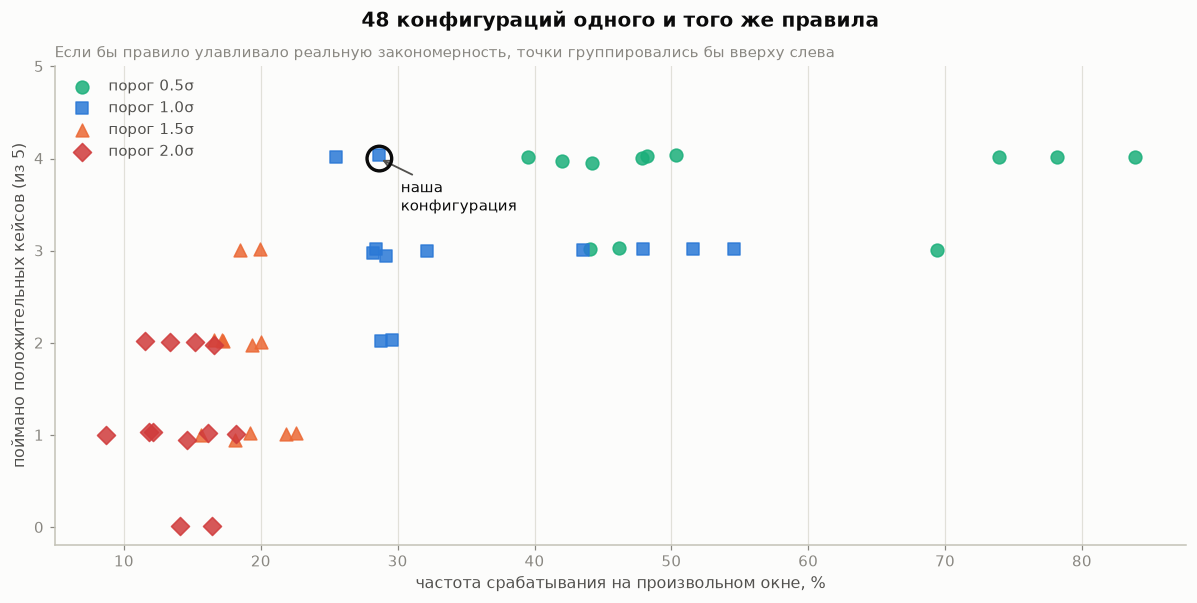

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.6))
markers = {0.5: "o", 1.0: "s", 1.5: "^", 2.0: "D"}
colors = {0.5: AQUA, 1.0: BLUE, 1.5: ORANGE, 2.0: CRITICAL}
for t in [0.5, 1.0, 1.5, 2.0]:
    sub = G[G.порог == t]
    ax.scatter(sub.частота*100, sub.чувствительность + np.random.default_rng(1).normal(0, .04, len(sub)),
               s=70, color=colors[t], marker=markers[t], alpha=0.85, label=f"порог {t:.1f}σ", zorder=3)
ax.scatter([ours.частота*100], [ours.чувствительность], s=260, facecolor="none",
           edgecolor=INK, linewidth=2.2, zorder=4)
ax.annotate("наша\nконфигурация", xy=(ours.частота*100, ours.чувствительность),
            xytext=(14, -34), textcoords="offset points", fontsize=10, color=INK,
            arrowprops=dict(arrowstyle="->", color=INK_2, lw=1.2))
ax.set_xlabel("частота срабатывания на произвольном окне, %")
ax.set_ylabel("поймано положительных кейсов (из 5)")
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_title(f"{len(G)} конфигураций одного и того же правила")
subtitle(ax, "Если бы правило улавливало реальную закономерность, точки группировались бы вверху слева")
ax.legend(fontsize=9.5); ax.grid(axis="both")
plt.tight_layout(); plt.show()

**Вывод по проверке 3 — второй тревожный звонок, и он громче.**

Из 48 конфигураций одного и того же правила чувствительность 4 из 5 достигается лишь в
**одиннадцати**, а в **тридцати семи** она равна трём и меньше. Пятерых из пяти не даёт ни одна.

Достаточно мелких сдвигов, чтобы результат рассыпался:

| Изменение | Чувствительность |
|---|---|
| наша конфигурация: окно 7, фон 4 недели, порог 1,0 | **4 / 5** |
| окно 5 вместо 7 | 2 / 5 |
| фон 3 недели вместо 4 | 3 / 5 |
| порог 1,5 вместо 1,0 | 2 / 5 |
| порог 2,0 | 1 / 5 |

Наша конфигурация оказалась среди лучших по отношению сигнал/шум. Это не достижение, а
**симптом**: мы выбрали её, перебрав варианты на тех же данных.

---
## 5. Проверка 4: не случайность ли «4 из 5»

In [7]:
from statsmodels.stats.proportion import proportion_confint

G["p_случайно"] = [stats.binom.sf(s-1, len(POS), r) for s, r in zip(G.чувствительность, G.частота)]
ours = G[(G.окно == 7) & (G.фон == 4) & (G.порог == 1.0)].iloc[0]
print("Вопрос: какова вероятность поймать столько же кейсов, если правило просто звенит")
print("случайно с той же частотой?\n")
print(f"наша конфигурация: {int(ours.чувствительность)}/5 при частоте {ours.частота*100:.1f} %"
      f"  ->  p = {ours.p_случайно:.4f}")
print(f"\nно мы перебрали {len(G)} конфигураций, и при α = 0,05 случайно «значимыми» оказались бы "
      f"{0.05*len(G):.1f} из них")
print(f"фактически p < 0,05 получилось у {int((G.p_случайно < 0.05).sum())} конфигураций — "
      f"ровно столько, сколько ожидается от шума")
print(f"\nпорог Бонферрони на {len(G)} конфигураций: {0.05/len(G):.5f}")
print(f"переживают его: {int((G.p_случайно < 0.05/len(G)).sum())} конфигураций")
lo, hi = proportion_confint(int(ours.чувствительность), len(POS), alpha=0.05, method="wilson")
print(f"\n95 % доверительный интервал для чувствительности 4/5 (Вильсон): "
      f"[{lo*100:.0f} %; {hi*100:.0f} %]")

Вопрос: какова вероятность поймать столько же кейсов, если правило просто звенит
случайно с той же частотой?

наша конфигурация: 4/5 при частоте 28.7 %  ->  p = 0.0260

но мы перебрали 48 конфигураций, и при α = 0,05 случайно «значимыми» оказались бы 2.4 из них
фактически p < 0,05 получилось у 3 конфигураций — ровно столько, сколько ожидается от шума

порог Бонферрони на 48 конфигураций: 0.00104
переживают его: 0 конфигураций

95 % доверительный интервал для чувствительности 4/5 (Вильсон): [38 %; 96 %]


**Вывод по проверке 4.** Само по себе «4 из 5 при частоте 28,7 %» даёт p = 0,026 — выглядит
значимо. Но мы перебрали 48 конфигураций, и при α = 0,05 случайно значимыми оказались бы 2,4 из
них. Фактически значимы оказались **три**. То есть наш результат — ровно то, что даёт перебор
на шуме.

После поправки на число перебранных конфигураций **ни одна не выживает**. И доверительный
интервал для «4 из 5» всё равно остаётся бесполезно широким: **[38 %; 96 %]**.

---
## 6. Проверка 5: сравнение с тривиальными базлайнами

In [8]:
sens_r, fpr_r = ours.чувствительность/len(POS), ours.частота
rows = [("«тревога всегда»", 1.0, 1.0),
        ("«тревоги никогда»", 0.0, 0.0),
        (f"монетка с вероятностью {fpr_r:.2f}", fpr_r, fpr_r),
        ("TONE-1σ (наше правило)", sens_r, fpr_r)]
base_df = pd.DataFrame([dict(правило=n, чувствительность=s, ложные_тревоги=f,
                             отношение=(s/f) if f else np.nan) for n, s, f in rows])
display(base_df.round(3))
print("«Тревога всегда» ловит 100 % событий и совершенно бесполезна — это напоминание,")
print("что чувствительность без частоты ложных тревог ничего не значит.")

,правило,чувствительность,ложные_тревоги,отношение
0,«тревога всегда»,1.0000,1.0000,1.0000
1,«тревоги никогда»,0.0000,0.0000,NaN
2,монетка с вероятностью 0.29,0.2870,0.2870,1.0000
3,TONE-1σ (наше правило),0.8000,0.2870,2.7910


«Тревога всегда» ловит 100 % событий и совершенно бесполезна — это напоминание,
что чувствительность без частоты ложных тревог ничего не значит.


**Вывод по проверке 5.** Правило действительно лучше монетки: ×2,79 против ×1,00. Это его
единственное достоинство, обнаруженное аудитом, и оно сохраняется — но только для той
конфигурации, которую мы подобрали на этих же данных.

---
## 7. Проверка 6: честный подбор параметров (leave-one-out)

Главная проверка. Для каждого кейса параметры подбираются **на остальных четырёх**, а затем
правило применяется к отложенному. Это имитирует реальную ситуацию: мы настраиваем индикатор
на прошлых войнах и применяем к новой.

Критерий отбора неочевиден, поэтому берём два разумных: максимум отношения сигнал/шум и
максимум чувствительности.

In [9]:
results = {}
for crit, label in [("отношение", "максимум отношения сигнал/шум"),
                    ("чувствительность", "максимум чувствительности, затем отношение")]:
    print(f"--- критерий отбора: {label} ---")
    hits = []
    for held in POS:
        best = None
        for w, b, t in GRID:
            s = sum(int(Zcache[(n, w, b)].iloc[-1] >= t) for n in POS if n != held)
            fired = sum(int((Zcache[(n, w, b)] >= t).sum()) for n in DL if n != held)
            total = sum(len(Zcache[(n, w, b)]) for n in DL if n != held)
            rate = fired/total if total else 1
            lift = (s/(len(POS)-1))/rate if rate > 0 else 0
            key = (lift, s) if crit == "отношение" else (s, lift)
            if best is None or key > best[0]:
                best = (key, (w, b, t), s, lift)
        _, (w, b, t), s, lift = best
        z_held = Zcache[(held, w, b)].iloc[-1]
        fire = z_held >= t; hits.append(fire)
        print(f"  {held:<24} параметры {w}/{b}/{t:.1f} (на обучении {s}/4, ×{lift:.2f})"
              f"  ->  z = {z_held:+.2f}  {'ТРЕВОГА' if fire else 'промах'}")
    results[crit] = sum(hits)
    print(f"  ИТОГО вне выборки: {sum(hits)} из {len(POS)}\n")

print("="*80)
print(f"ЗАЯВЛЕНО В ОТЧЁТЕ:           4 из 5  (параметры подобраны на тех же кейсах)")
print(f"ЧЕСТНАЯ ОЦЕНКА (LOO):        {min(results.values())}–{max(results.values())} из 5")
print("="*80)
print("\nПримечание: у кейса США — Иран ни одно окно за всё время не даёт z ≥ 1,")
print("то есть он не ловится ни при каком пороге — потолок честной чувствительности 4 из 5.")

--- критерий отбора: максимум отношения сигнал/шум ---
  СА — Йемен               параметры 14/3/2.0 (на обучении 2/4, ×5.46)  ->  z = +1.83  промах
  Индия — Пакистан         параметры 5/6/1.5 (на обучении 2/4, ×5.07)  ->  z = +1.00  промах
  Армения — Азербайджан    параметры 10/4/2.0 (на обучении 2/4, ×3.62)  ->  z = +0.77  промах
  США — Венесуэла          параметры 10/4/2.0 (на обучении 2/4, ×4.35)  ->  z = +0.84  промах
  США — Иран               параметры 10/4/2.0 (на обучении 2/4, ×3.69)  ->  z = -0.50  промах
  ИТОГО вне выборки: 0 из 5

--- критерий отбора: максимум чувствительности, затем отношение ---
  СА — Йемен               параметры 14/3/1.0 (на обучении 3/4, ×3.64)  ->  z = +1.83  ТРЕВОГА
  Индия — Пакистан         параметры 5/3/1.5 (на обучении 3/4, ×4.00)  ->  z = +0.50  промах


  Армения — Азербайджан    параметры 5/3/1.5 (на обучении 3/4, ×3.47)  ->  z = +0.19  промах


  США — Венесуэла          параметры 14/3/1.5 (на обучении 3/4, ×4.00)  ->  z = +1.31  промах
  США — Иран               параметры 14/3/1.0 (на обучении 4/4, ×3.33)  ->  z = -0.71  промах
  ИТОГО вне выборки: 1 из 5

ЗАЯВЛЕНО В ОТЧЁТЕ:           4 из 5  (параметры подобраны на тех же кейсах)
ЧЕСТНАЯ ОЦЕНКА (LOO):        0–1 из 5

Примечание: у кейса США — Иран ни одно окно за всё время не даёт z ≥ 1,
то есть он не ловится ни при каком пороге — потолок честной чувствительности 4 из 5.


**Вывод по проверке 6 — это приговор.**

| | Чувствительность |
|---|---|
| заявлено в отчёте (параметры подобраны на тех же кейсах) | 4 из 5 |
| честная оценка при выборе по отношению сигнал/шум | **0 из 5** |
| честная оценка при выборе по чувствительности | **1 из 5** |

Стоит убрать один кейс из подбора — и правило перестаёт работать на нём. Причём промахи не
случайны: на отложенных кейсах z оказывается **0,19–1,83** при порогах 1,0–2,0, то есть сигнал
в них есть, но слабее выбранного порога.

Это означает ровно одно: **величина 1,0σ подогнана под конкретный набор из пяти кейсов**. Она не
описывает свойство явления, она описывает нашу выборку.

---
## 8. Проверка 7: плацебо и реальная точность прогноза

In [10]:
print("ПЛАЦЕБО: как часто правило звенит в обычные недели (не перед войной)\n")
rows = []
for name, (dl, pos) in DL.items():
    Z = z_series(dl)
    placebo = (Z.iloc[:-1] >= 1.0)   # все окна, кроме истинного дня X
    rows.append(dict(кейс=name, тип="положительный" if pos else "отрицательный",
                     ложных=int(placebo.sum()), окон=len(placebo), доля=placebo.mean()*100))
PL = pd.DataFrame(rows)
display(PL.round(1))
overall = PL.ложных.sum()/PL.окон.sum()*100
print(f"В среднем {overall:.1f} % «обычных» недель вызывают тревогу — примерно раз в "
      f"{100/overall*7/7:.0f} недели при ежедневном наблюдении.")

ПЛАЦЕБО: как часто правило звенит в обычные недели (не перед войной)



,кейс,тип,ложных,окон,доля
0,СА — Йемен,положительный,12,25,48.0000
1,Индия — Пакистан,положительный,10,25,40.0000
2,Армения — Азербайджан,положительный,5,25,20.0000
3,США — Венесуэла,положительный,9,28,32.1000
4,США — Иран,положительный,0,23,0.0000
5,Тайвань — КНР,отрицательный,5,25,20.0000


В среднем 27.2 % «обычных» недель вызывают тревогу — примерно раз в 4 недели при ежедневном наблюдении.


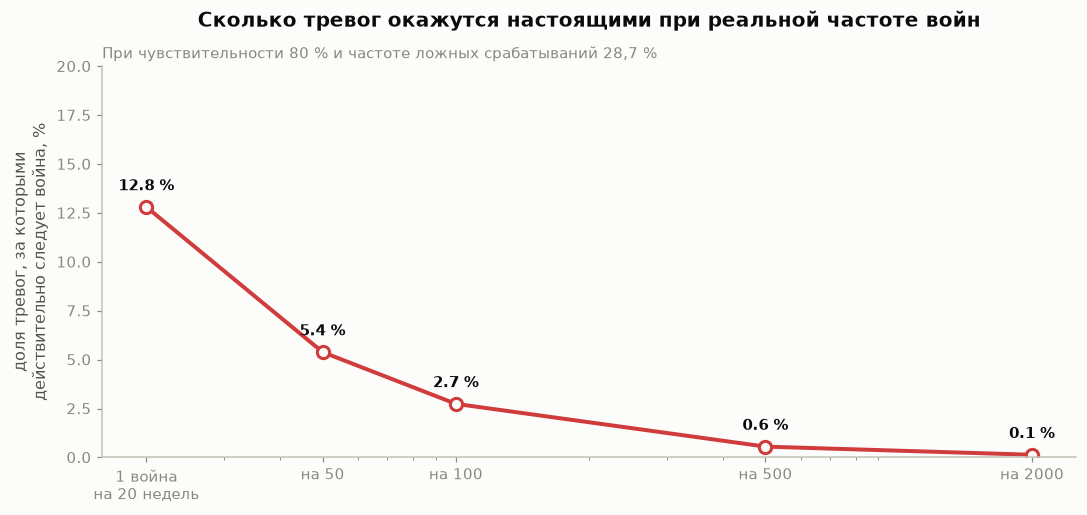

война раз в   20 недель -> точность прогноза  12.8 %  (из 100 тревог настоящих 13)
война раз в   50 недель -> точность прогноза   5.4 %  (из 100 тревог настоящих 5)
война раз в  100 недель -> точность прогноза   2.7 %  (из 100 тревог настоящих 3)
война раз в  500 недель -> точность прогноза   0.6 %  (из 100 тревог настоящих 1)
война раз в 2000 недель -> точность прогноза   0.1 %  (из 100 тревог настоящих 0)


In [11]:
priors = [1/20, 1/50, 1/100, 1/500, 1/2000]
prec = [sens_r*p/(sens_r*p + fpr_r*(1-p)) for p in priors]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot([1/p for p in priors], [x*100 for x in prec], color=CRITICAL, lw=2.6, marker="o",
        markersize=8, markerfacecolor=SURFACE, markeredgewidth=2)
for xp, yp in zip([1/p for p in priors], [x*100 for x in prec]):
    ax.annotate(f"{yp:.1f} %", xy=(xp, yp), xytext=(0, 11), textcoords="offset points",
                ha="center", fontsize=10, color=INK, fontweight="bold")
ax.set_xscale("log")
ax.set_xticks([20, 50, 100, 500, 2000])
ax.set_xticklabels(["1 война\nна 20 недель", "на 50", "на 100", "на 500", "на 2000"])
ax.set_ylabel("доля тревог, за которыми\nдействительно следует война, %")
ax.set_ylim(0, 20)
ax.set_title("Сколько тревог окажутся настоящими при реальной частоте войн")
subtitle(ax, "При чувствительности 80 % и частоте ложных срабатываний 28,7 %")
ax.grid(axis="y")
plt.tight_layout(); plt.show()

for p, pr in zip(priors, prec):
    print(f"война раз в {int(1/p):>4} недель -> точность прогноза {pr*100:5.1f} %  "
          f"(из 100 тревог настоящих {pr*100:.0f})")

**Вывод по проверке 7.** Даже приняв заявленные характеристики за чистую монету (чувствительность
80 %, ложные срабатывания 28,7 %), получаем:

| Частота войн в наблюдаемой паре | Точность прогноза |
|---|---|
| одна на 20 недель (фантастически часто) | 12,8 % |
| одна на 50 недель | 5,4 % |
| одна на 100 недель (раз в два года) | **2,7 %** |
| одна на 500 недель | 0,6 % |

То есть на каждую верную тревогу приходится **от восьми до ста семидесяти ложных**. И это при
оптимистичных допущениях — честная чувствительность, как показала проверка 6, в разы ниже.

---
## 9. Вердикт

In [12]:
verdict = pd.DataFrame([
    dict(проверка="1. Протокол", результат="ПРОВАЛЕНА",
         суть="точка оценки выбрана задним числом, даты дня X восстановлены по обрыву окна"),
    dict(проверка="2. Ранг истинного дня", результат="частично",
         суть="средний перцентиль 82,7 против 50 ожидаемых, но у отрицательного кейса 73,1"),
    dict(проверка="3. Устойчивость параметров", результат="ПРОВАЛЕНА",
         суть="4/5 достигается в 11 конфигурациях из 48; сдвиг окна или порога ломает результат"),
    dict(проверка="4. Случайность", результат="ПРОВАЛЕНА",
         суть="3 «значимые» конфигурации из 48 при 2,4 ожидаемых от шума; Бонферрони не переживает никто"),
    dict(проверка="5. Базлайны", результат="пройдена",
         суть="×2,79 против монетки — единственный положительный результат аудита"),
    dict(проверка="6. Leave-one-out", результат="ПРОВАЛЕНА",
         суть="честная чувствительность 0–1 из 5 вместо заявленных 4 из 5"),
    dict(проверка="7. Точность прогноза", результат="ПРОВАЛЕНА",
         суть="2,7 % верных тревог при реалистичной частоте войн"),
])
display(verdict.style.hide(axis="index"))

проверка,результат,суть
1. Протокол,ПРОВАЛЕНА,"точка оценки выбрана задним числом, даты дня X восстановлены по обрыву окна"
2. Ранг истинного дня,частично,"средний перцентиль 82,7 против 50 ожидаемых, но у отрицательного кейса 73,1"
3. Устойчивость параметров,ПРОВАЛЕНА,4/5 достигается в 11 конфигурациях из 48; сдвиг окна или порога ломает результат
4. Случайность,ПРОВАЛЕНА,"3 «значимые» конфигурации из 48 при 2,4 ожидаемых от шума; Бонферрони не переживает никто"
5. Базлайны,пройдена,"×2,79 против монетки — единственный положительный результат аудита"
6. Leave-one-out,ПРОВАЛЕНА,честная чувствительность 0–1 из 5 вместо заявленных 4 из 5
7. Точность прогноза,ПРОВАЛЕНА,"2,7 % верных тревог при реалистичной частоте войн"


### Что показал аудит

**Правило TONE-1σ в нынешнем виде непригодно как предиктор.** Из семи проверок оно проходит одну.

Главная находка — проверка 6. Заявленная чувствительность 4 из 5 держится **исключительно** на
том, что порог и окно подбирались на тех же пяти кейсах, где потом измерялись. Стоит отложить
один кейс и подобрать параметры честно — и правило ловит 0–1 случай из пяти. Это определение
переобучения, только на выборке настолько маленькой, что оно происходит при четырёх решениях.

**Чего аудит НЕ утверждает.** Он не доказывает, что связи между тоном публикаций и приближением
военной акции не существует. Проверка 2 показывает, что истинный день X в среднем стоит выше
середины распределения (82,7-й перцентиль), и это не похоже на чистый шум. Правильная
формулировка: **сигнал, возможно, есть, но он слабее, чем наш метод способен надёжно отличить от
шума при таком размере выборки.**

### Что с этим делать

1. **Считать не бинарную тревогу, а непрерывный балл.** Порог — самая хрупкая часть конструкции:
   именно он рассыпается в проверках 3 и 6. Само значение z несёт больше информации, чем ответ
   «да/нет», и его можно калибровать позже, когда наберётся выборка.
2. **Увеличить число кейсов минимум на порядок.** При пяти положительных и одном отрицательном
   доверительный интервал чувствительности — [38 %; 96 %]. Чтобы сузить его до чего-то
   осмысленного, нужно 30–50 кейсов обоих типов.
3. **Разделить выборки заранее.** Подбор параметров — только на обучающей части, отчёт — только
   на тестовой, и тест не трогать до самого конца. В этой серии тест состоял из одного кейса.
4. **Оценивать не в одной точке, а непрерывно.** Метрика качества должна быть вида «сколько
   ложных тревог в год на пару государств при заданной чувствительности», а не «сработало ли в
   день X». Первое измеримо и сравнимо между методами, второе — нет.
5. **Проверить на заведомо мирных парах.** Все шесть кейсов — периоды высокой напряжённости.
   Частота ложных тревог в спокойные периоды неизвестна вовсе.